Input: `data/preprocessed/WESAD/S{id}_clean.pkl`  
Output: windows generated on-the-fly (no serialized window files)

In [12]:
import numpy as np
import pandas as pd
import wesad_preprocess as wp

## 1. Sliding Window Extraction Function

Given a continuous 1D array sampled at rate `fs`, extract overlapping windows of length `window_sec` shifted by `shift_sec`.

In [13]:
def extract_sliding_windows(arr, label_arr, fs, window_sec, shift_sec):
    """
    Extracts 2D array of windows shape (n_windows, window_samples) and 
    majority or center label for each window.
    """
    arr = np.asarray(arr)
    label_arr = np.asarray(label_arr)
    
    win_len = int(round(window_sec * fs))
    shift_len = int(round(shift_sec * fs))
    
    if len(arr) < win_len:
        return np.array([]), np.array([])
        
    n_windows = (len(arr) - win_len) // shift_len + 1
    
    # Extract windows using stride tricks for zero memory copy during slice
    shape = (n_windows, win_len)
    strides = (arr.strides[0] * shift_len, arr.strides[0])
    
    if arr.ndim == 1:
        windows = np.lib.stride_tricks.as_strided(arr, shape=shape, strides=strides)
    else:
        # Multi-axis (e.g., 3-axis ACC)
        n_channels = arr.shape[1]
        shape_multi = (n_windows, win_len, n_channels)
        strides_multi = (arr.strides[0] * shift_len, arr.strides[0], arr.strides[1])
        windows = np.lib.stride_tricks.as_strided(arr, shape=shape_multi, strides=strides_multi)
        
    # Window label (majority vote across the window)
    label_shape = (n_windows, win_len)
    label_strides = (label_arr.strides[0] * shift_len, label_arr.strides[0])
    win_labels = np.lib.stride_tricks.as_strided(label_arr, shape=label_shape, strides=label_strides)
    
    # Take majority label (or mean > 0.5 for binary 0/1)
    labels = (win_labels.mean(axis=1) >= 0.5).astype(int)
    
    return windows, labels

def window_subject(clean_data, shift_sec=SHIFT_SEC):
    """
    Apply sliding window extraction across all signals for a subject.
    ACC signals use 5s window; all other signals use 60s window.
    """
    windowed = {
        'subject': clean_data['subject'],
        'drop_excluded': clean_data['drop_excluded'],
        'shift_sec': shift_sec,
        'window_sec_general': WINDOW_SEC_GENERAL,
        'window_sec_acc': WINDOW_SEC_ACC,
        'signal': {'chest': {}, 'wrist': {}},
        'label': {'chest': {}, 'wrist': {}},
        'fs': clean_data['fs'],
    }
    
    for loc in ('chest', 'wrist'):
        for name, arr in clean_data['signal'][loc].items():
            fs = clean_data['fs'][loc][name]
            lab = clean_data['label'][loc][name]
            
            win_sec = WINDOW_SEC_ACC if 'ACC' in name else WINDOW_SEC_GENERAL
            wins, win_labs = extract_sliding_windows(arr, lab, fs, win_sec, shift_sec)
            
            windowed['signal'][loc][name] = wins
            windowed['label'][loc][name] = win_labs
            
    return windowed

## 2. Single-Subject Walkthrough

In [14]:
clean = wp.load_clean_subject(SUBJECTS[0])
wdw = window_subject(clean)

rows = []
for loc in ('chest', 'wrist'):
    for name, arr in wdw['signal'][loc].items():
        lab = wdw['label'][loc][name]
        win_sec = wdw['window_sec_acc'] if 'ACC' in name else wdw['window_sec_general']
        rows.append({
            'location': loc,
            'signal': name,
            'fs_hz': wdw['fs'][loc][name],
            'window_sec': win_sec,
            'shift_sec': wdw['shift_sec'],
            'window_shape': arr.shape,
            'label_shape': lab.shape,
            'stress_ratio': round(float(lab.mean()), 3) if len(lab) > 0 else 0.0
        })

pd.DataFrame(rows)

,location,signal,fs_hz,window_sec,shift_sec,window_shape,label_shape,stress_ratio
0,chest,ACC,700,5.0,0.25,"(8465, 3500, 3)","(8465,)",0.291
1,chest,ECG,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
2,chest,EMG,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
3,chest,EDA,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
4,chest,EDA_SCR,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
5,chest,EDA_SCL,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
6,chest,Temp,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
7,chest,Resp,700,60.0,0.25,"(8245, 42000)","(8245,)",0.298
8,wrist,ACC,32,5.0,0.25,"(8465, 160, 3)","(8465,)",0.291
9,wrist,BVP,64,60.0,0.25,"(8245, 3840)","(8245,)",0.298


## 3. Process & Save All Subjects

In [15]:
# ==============================================================================
# ON-THE-FLY WINDOWING (Memory & Disk Saving Design)
# ==============================================================================
# Saving materialized 2D window matrices across all 15 subjects requires ~100+ GB
# of disk space and repeatedly triggers OOM.
# Instead, windows are generated on-the-fly during Stage 5 (Feature Extraction)
# using a zero-copy generator / slice helper:

def iter_subject_windows(clean_data, shift_sec=SHIFT_SEC):
    """
    Yields window slices on-the-fly without saving gigantic multi-gigabyte pickles to disk.
    ACC: 5s window. Other signals: 60s window.
    """
    # Use index-based sliding windows per location and sensor
    locations = ('chest', 'wrist')
    for loc in locations:
        for name, arr in clean_data['signal'][loc].items():
            fs = clean_data['fs'][loc][name]
            lab = clean_data['label'][loc][name]
            win_sec = WINDOW_SEC_ACC if 'ACC' in name else WINDOW_SEC_GENERAL
            wins, win_labs = extract_sliding_windows(arr, lab, fs, win_sec, shift_sec)
            yield loc, name, wins, win_labs

print("Windowing is configured to run on-the-fly during feature extraction.")
print("No multi-gigabyte serialized window files need to be saved to disk.")

Windowing is configured to run on-the-fly during feature extraction.
No multi-gigabyte serialized window files need to be saved to disk.


## 4. Preview Windowed Signals

### 4.A. Preview Specific Window

Subject S2 window summary:


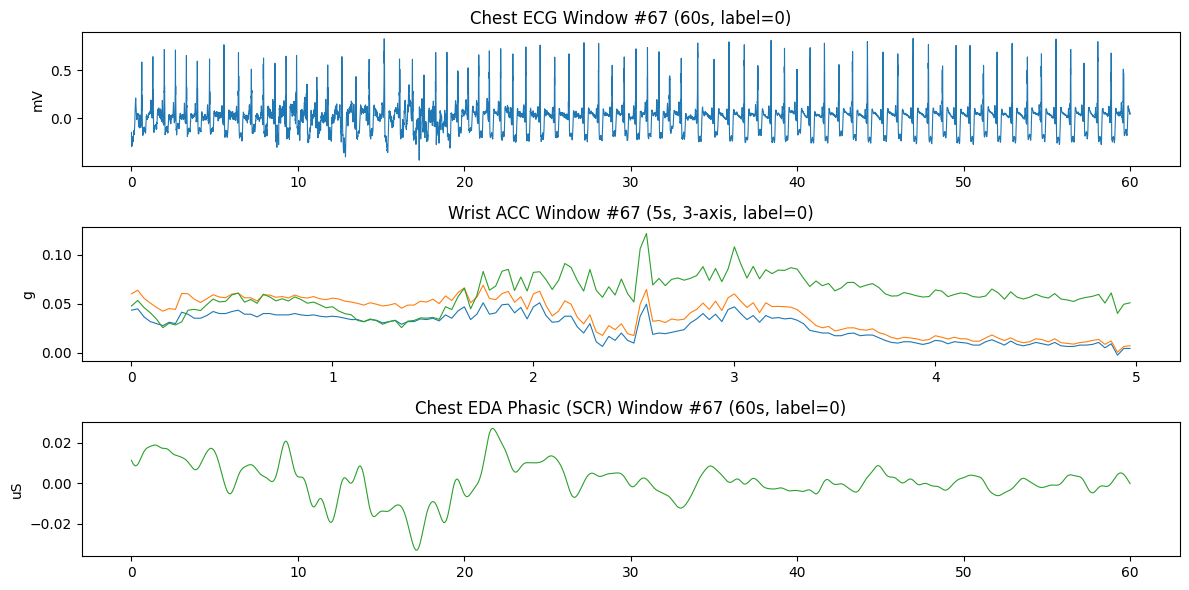

In [16]:
import matplotlib.pyplot as plt

# Preview directly from clean subject on-the-fly
PREVIEW_SUBJECT = SUBJECTS[0]
WINDOW_NO = 67 # Change this index to view different windows

clean_data = wp.load_clean_subject(PREVIEW_SUBJECT)
wdw_data = window_subject(clean_data)

print(f"Subject {wdw_data['subject']} window summary:")

# Plot sample windows for ECG, ACC, and EDA
fig, axes = plt.subplots(3, 1, figsize=(12, 6))

ecg_win = wdw_data['signal']['chest']['ECG'][WINDOW_NO]
t_ecg = np.arange(len(ecg_win)) / wdw_data['fs']['chest']['ECG']
axes[0].plot(t_ecg, ecg_win, color='tab:blue', lw=0.8)
axes[0].set_title(f"Chest ECG Window #{WINDOW_NO} (60s, label={wdw_data['label']['chest']['ECG'][WINDOW_NO]})")
axes[0].set_ylabel("mV")

acc_win = wdw_data['signal']['wrist']['ACC'][WINDOW_NO]
t_acc = np.arange(len(acc_win)) / wdw_data['fs']['wrist']['ACC']
axes[1].plot(t_acc, acc_win, lw=0.8)
axes[1].set_title(f"Wrist ACC Window #{WINDOW_NO} (5s, 3-axis, label={wdw_data['label']['wrist']['ACC'][WINDOW_NO]})")
axes[1].set_ylabel("g")

eda_win = wdw_data['signal']['chest']['EDA_SCR'][WINDOW_NO]
t_eda = np.arange(len(eda_win)) / wdw_data['fs']['chest']['EDA_SCR']
axes[2].plot(t_eda, eda_win, color='tab:green', lw=0.8)
axes[2].set_title(f"Chest EDA Phasic (SCR) Window #{WINDOW_NO} (60s, label={wdw_data['label']['chest']['EDA_SCR'][WINDOW_NO]})")
axes[2].set_ylabel("uS")

plt.tight_layout()
plt.show()

### 4.B. Preview Random Windows

Previewing random windows: [359, 1577, 7438]


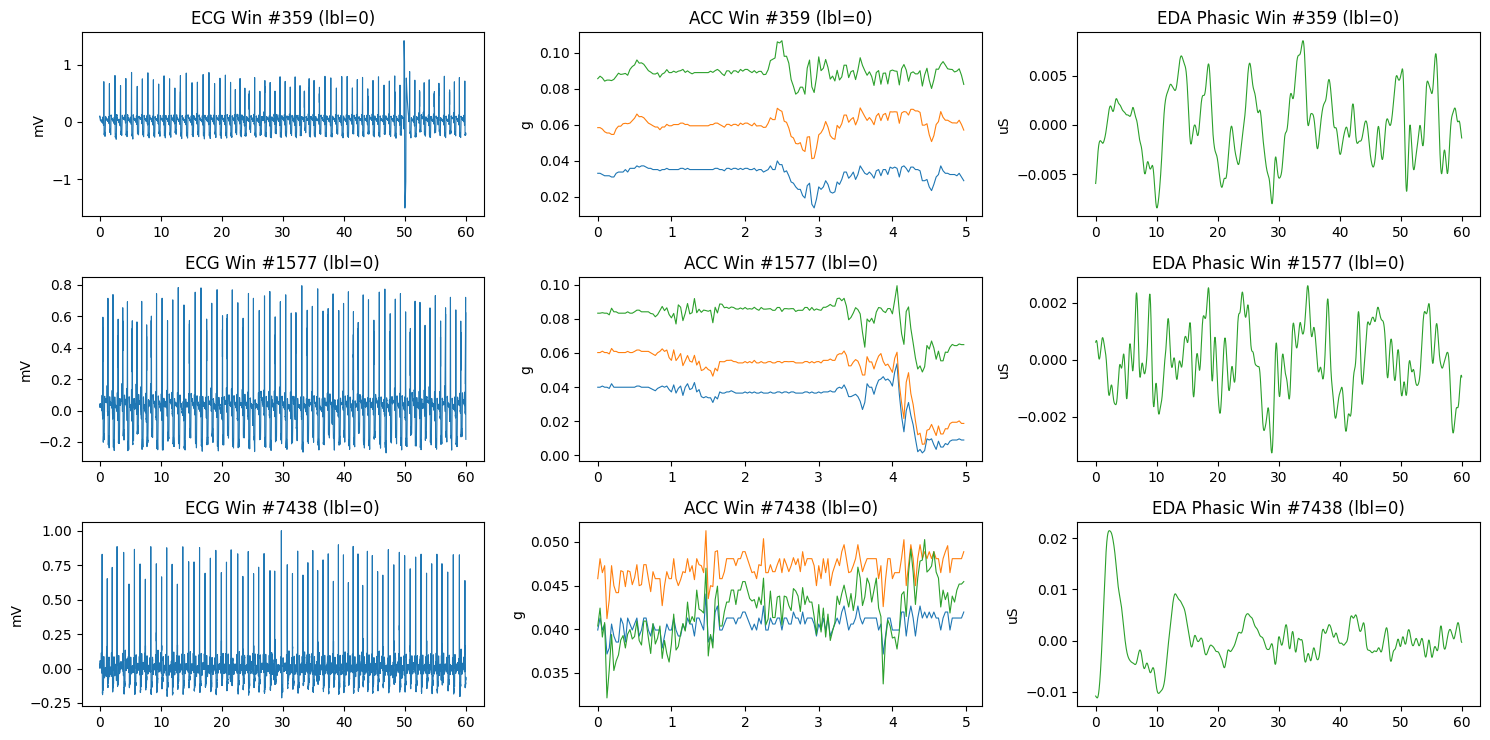

In [28]:
# Preview 3 randomly selected windows for a subject (completely random each run)
import time

N_RANDOM_WINDOWS = 3

# Use current time in nanoseconds for random seed to ensure new random selection on each execution
seed = int(time.time_ns()) % (2**32)
rng = np.random.default_rng(seed)

total_wins = len(wdw_data['signal']['chest']['ECG'])
random_win_indices = rng.choice(total_wins, size=N_RANDOM_WINDOWS, replace=False)
random_win_indices.sort()

print(f"Previewing random windows: {random_win_indices.tolist()}")

fig, axes = plt.subplots(N_RANDOM_WINDOWS, 3, figsize=(15, 2.5 * N_RANDOM_WINDOWS))

for i, win_idx in enumerate(random_win_indices):
    # ECG
    ecg_win = wdw_data['signal']['chest']['ECG'][win_idx]
    t_ecg = np.arange(len(ecg_win)) / wdw_data['fs']['chest']['ECG']
    label_ecg = wdw_data['label']['chest']['ECG'][win_idx]
    axes[i, 0].plot(t_ecg, ecg_win, color='tab:blue', lw=0.8)
    axes[i, 0].set_title(f"ECG Win #{win_idx} (lbl={label_ecg})")
    axes[i, 0].set_ylabel("mV")
    
    # ACC Wrist
    acc_win = wdw_data['signal']['wrist']['ACC'][win_idx]
    t_acc = np.arange(len(acc_win)) / wdw_data['fs']['wrist']['ACC']
    label_acc = wdw_data['label']['wrist']['ACC'][win_idx]
    axes[i, 1].plot(t_acc, acc_win, lw=0.8)
    axes[i, 1].set_title(f"ACC Win #{win_idx} (lbl={label_acc})")
    axes[i, 1].set_ylabel("g")
    
    # EDA SCR
    eda_win = wdw_data['signal']['chest']['EDA_SCR'][win_idx]
    t_eda = np.arange(len(eda_win)) / wdw_data['fs']['chest']['EDA_SCR']
    label_eda = wdw_data['label']['chest']['EDA_SCR'][win_idx]
    axes[i, 2].plot(t_eda, eda_win, color='tab:green', lw=0.8)
    axes[i, 2].set_title(f"EDA Phasic Win #{win_idx} (lbl={label_eda})")
    axes[i, 2].set_ylabel("uS")

plt.tight_layout()
plt.show()